# DATA 3402 Final Project-Summer 2026

## **Assignment Submission Guidelines**


Please follow the guidelines below for submitting your assignment:

1. **Submission Deadline:**
   - All assignments must be submitted **no later than 11:59 PM the final exam day (08/07) Midnight**.
   - Late submissions will not be accepted.

2. **Submission Platform:**
   - Submit your assignment through **Canvas**.

3. **Required Files:**
   - **Jupyter Notebook file (.ipynb):** Submit the Jupyter Notebook file you used to complete the assignment. The file should contain your well-commented code.
   - **PDF Version (.pdf file):** Additionally, submit a PDF version of your Python code. This can be a printout or export of your script, showing all the code with any necessary explanations or output results included.

4. **File Naming Convention:**
   - Please name your files as follows: `Group Name_AssignmentName`
   - Example: `Group 1_Final_Project.ipynb` and `Group 1_Final_Project.pdf`

5. **Technical Issues:**
   - If you encounter any technical issues with Canvas or your submission, please contact the TAs immediately **before the deadline** to avoid penalties.


## Guideline

Your final project presentations will be held on Tuesday, August 4th, from 1:00 PM to 3:00 PM.

Each group will have approximately 20 minutes to present their project and findings.

**Please confirm and sign up for your group by midnight on July 23rd.**

The dataset list file contains the datasets assigned to each group.
You are not limited to these datasets—if you wish to use a different one, please contact Dr. Ce Brian Bian in advance to confirm its suitability.

This notebook serves as a step-by-step guide to help you complete your final project successfully.

This notebook outlines the steps you should follow. Note that you will be only considering classification projects.

## Data Loading and Initial Look

* Load the data.
* Count the number of rows (data points) and features.
* Any missing values?
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values?
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

df = pd.read_csv('springleaf-marketing-response/train.csv', low_memory=False)

for c in df.select_dtypes('float64').columns:
    df[c] = df[c].astype('float32')

In [2]:
assumed_placeholders = [-1,
                        96, 97, 98, 99,
                        996, 997, 998, 999,
                        9996, 9997, 9998, 9999,
                        999999996, 999999997, 999999998, 999999999]

rows, cols = df.shape
features = [c for c in df.columns if c not in ('ID', 'target')]
num_cols = df[features].select_dtypes(include=[np.number]).columns.tolist()
str_cols = [c for c in features if c not in num_cols]

print('Row and Feature count:')
print(f'Rows: {rows}')
print(f'Columns: {cols}')
print(f'Features: {len(features)}')

Row and Feature count:
Rows: 145231
Columns: 1934
Features: 1932


In [3]:
missing_count = df[features].isna().sum()
missing_pct = missing_count / rows
num_cells = rows * len(features)

print('Missing values:')
print(f'Features with >= 1 missing: {(missing_count > 0).sum()}')
print(f'Features >50% missing: {(missing_pct > 0.5).sum()}')
print(f'Features 100% missing: {(missing_pct == 1.0).sum()}')

plchldr_count = pd.Series(0, index=num_cols, dtype='int64')
plchldr_rows = []

for plchldr in assumed_placeholders:
    hit = (df[num_cols] == plchldr).sum()
    plchldr_count = plchldr_count + hit
    if hit.sum() > 0:
        plchldr_rows.append({'value': plchldr,
                              'columns': int((hit > 0).sum()),
                              'cells': int(hit.sum())})

plchldr_table = pd.DataFrame(plchldr_rows)
plchldr_table['pct_of_cells'] = (100 * plchldr_table['cells'] / num_cells).round(2)

print('\nAssumed Placeholders:')
print('We will assume certain values are placeholders for missing values.')
print('The true count of missing values is unknown, and is under-reported by pandas')
print('since pandas assumes these values are valid.')
display(plchldr_table)

Missing values:
Features with >= 1 missing: 525
Features >50% missing: 24
Features 100% missing: 3

Assumed Placeholders:
We will assume certain values are placeholders for missing values.
The true count of missing values is unknown, and is under-reported by pandas
since pandas assumes these values are valid.


,value,columns,cells,pct_of_cells
0,-1,117,4962052,1.77
1,96,473,555099,0.20
2,97,659,2535240,0.90
3,98,787,14530873,5.18
4,99,904,430255,0.15
5,998,399,8581074,3.06
6,999,456,143701,0.05
7,9998,219,6586376,2.35
8,9999,272,1139787,0.41
9,999999996,241,1375126,0.49


In [4]:
def group_size(n):

    if n <= 1:
        return 'constant (useless)'
    if n <= 10:
        return 'few values (2-10)'
    if n <= 20:
        return 'relatively diverse values (11-20)'
    return 'many values (21+)'

n_unique = df[features].nunique()
kind = df[features].dtypes.astype(str).apply(lambda d: 'number' if d.startswith(('int', 'float')) else 'text')
group = n_unique.apply(group_size)

print('Feature Table')
display(pd.crosstab(kind, group, rownames=['type'], colnames=['distinct values']))

print(f'Constant features (no information): {(n_unique <= 1).sum()}')
print(f'Features with 20 or fewer values: {(n_unique <= 20).sum()}')
print(f'Features more than half missing: {(missing_pct > 0.5).sum()}')

Feature Table


distinct values,constant (useless),few values (2-10),many values (21+),relatively diverse values (11-20)
type,,,,
number,41,439,1180,221
text,13,15,22,1


Constant features (no information): 54
Features with 20 or fewer values: 730
Features more than half missing: 24


In [31]:
print('Outliers:')
# TODO This needs to be re-written. Define an outlier.

Outliers:


In [6]:
target_counts = df['target'].value_counts().sort_index()

print('Class Imbalance:')
for value, count in target_counts.items():
    print(f'{value}: {count} ({round(100 * count / rows, 2)}%)')
print(f'Imbalance in the target variable is noticeable but not extreme.')

Class Imbalance:
0: 111458 (76.75%)
1: 33773 (23.25%)
Imbalance in the target variable is noticeable but not extreme.


In [7]:
print('The target and its encoding:')
print('For this project, the target is "target".')
print('dtpe: int64')
print('Values: {0, 1}')
print('Missing: 0')

The target and its encoding:
For this project, the target is "target".
dtpe: int64
Values: {0, 1}
Missing: 0


## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression:
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

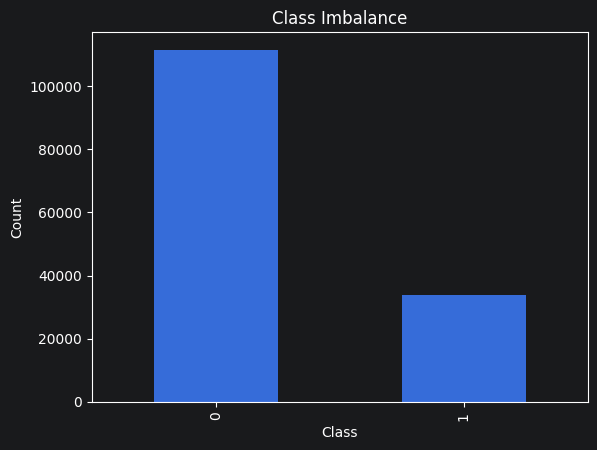

In [8]:
target_counts.plot.bar()
plt.title('Class Imbalance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

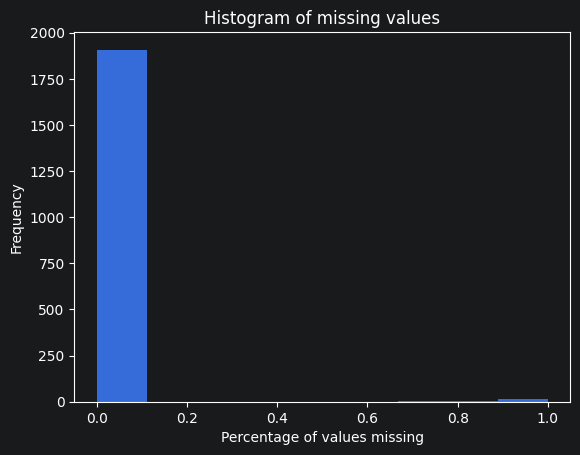

In [9]:
missing_pct.plot.hist(bins=9)
plt.title('Histogram of missing values')
plt.xlabel('Percentage of values missing')
plt.ylabel('Frequency')
plt.show()

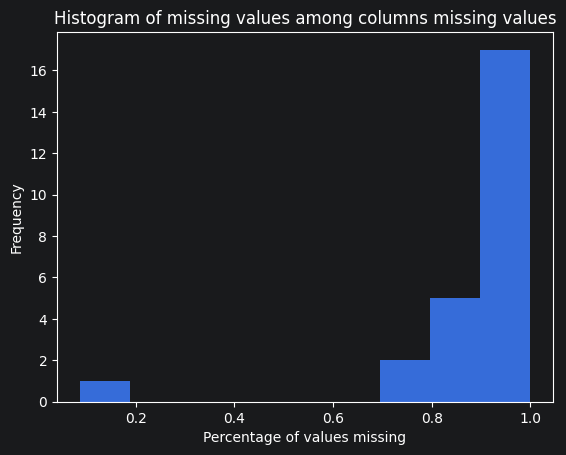

In [10]:
missing_pct[missing_pct > 0.01].plot.hist(bins=9)
plt.title('Histogram of missing values among columns missing values')
plt.xlabel('Percentage of values missing')
plt.ylabel('Frequency')
plt.show()

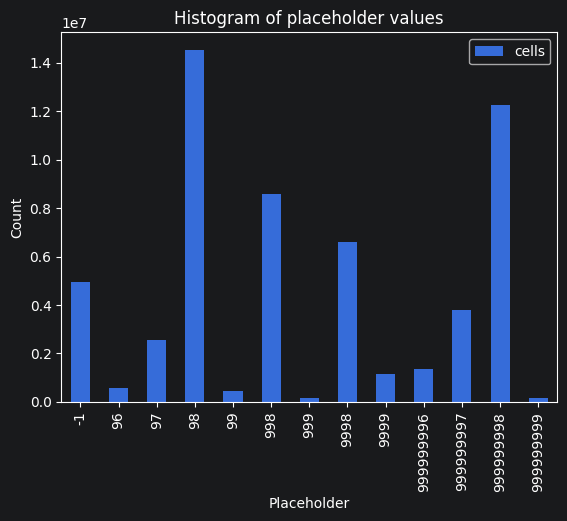

In [33]:
plchldr_table.plot.bar(x='value', y='cells')
plt.xlabel('Placeholder')
plt.ylabel('Count')
plt.title('Histogram of placeholder values')
plt.show()

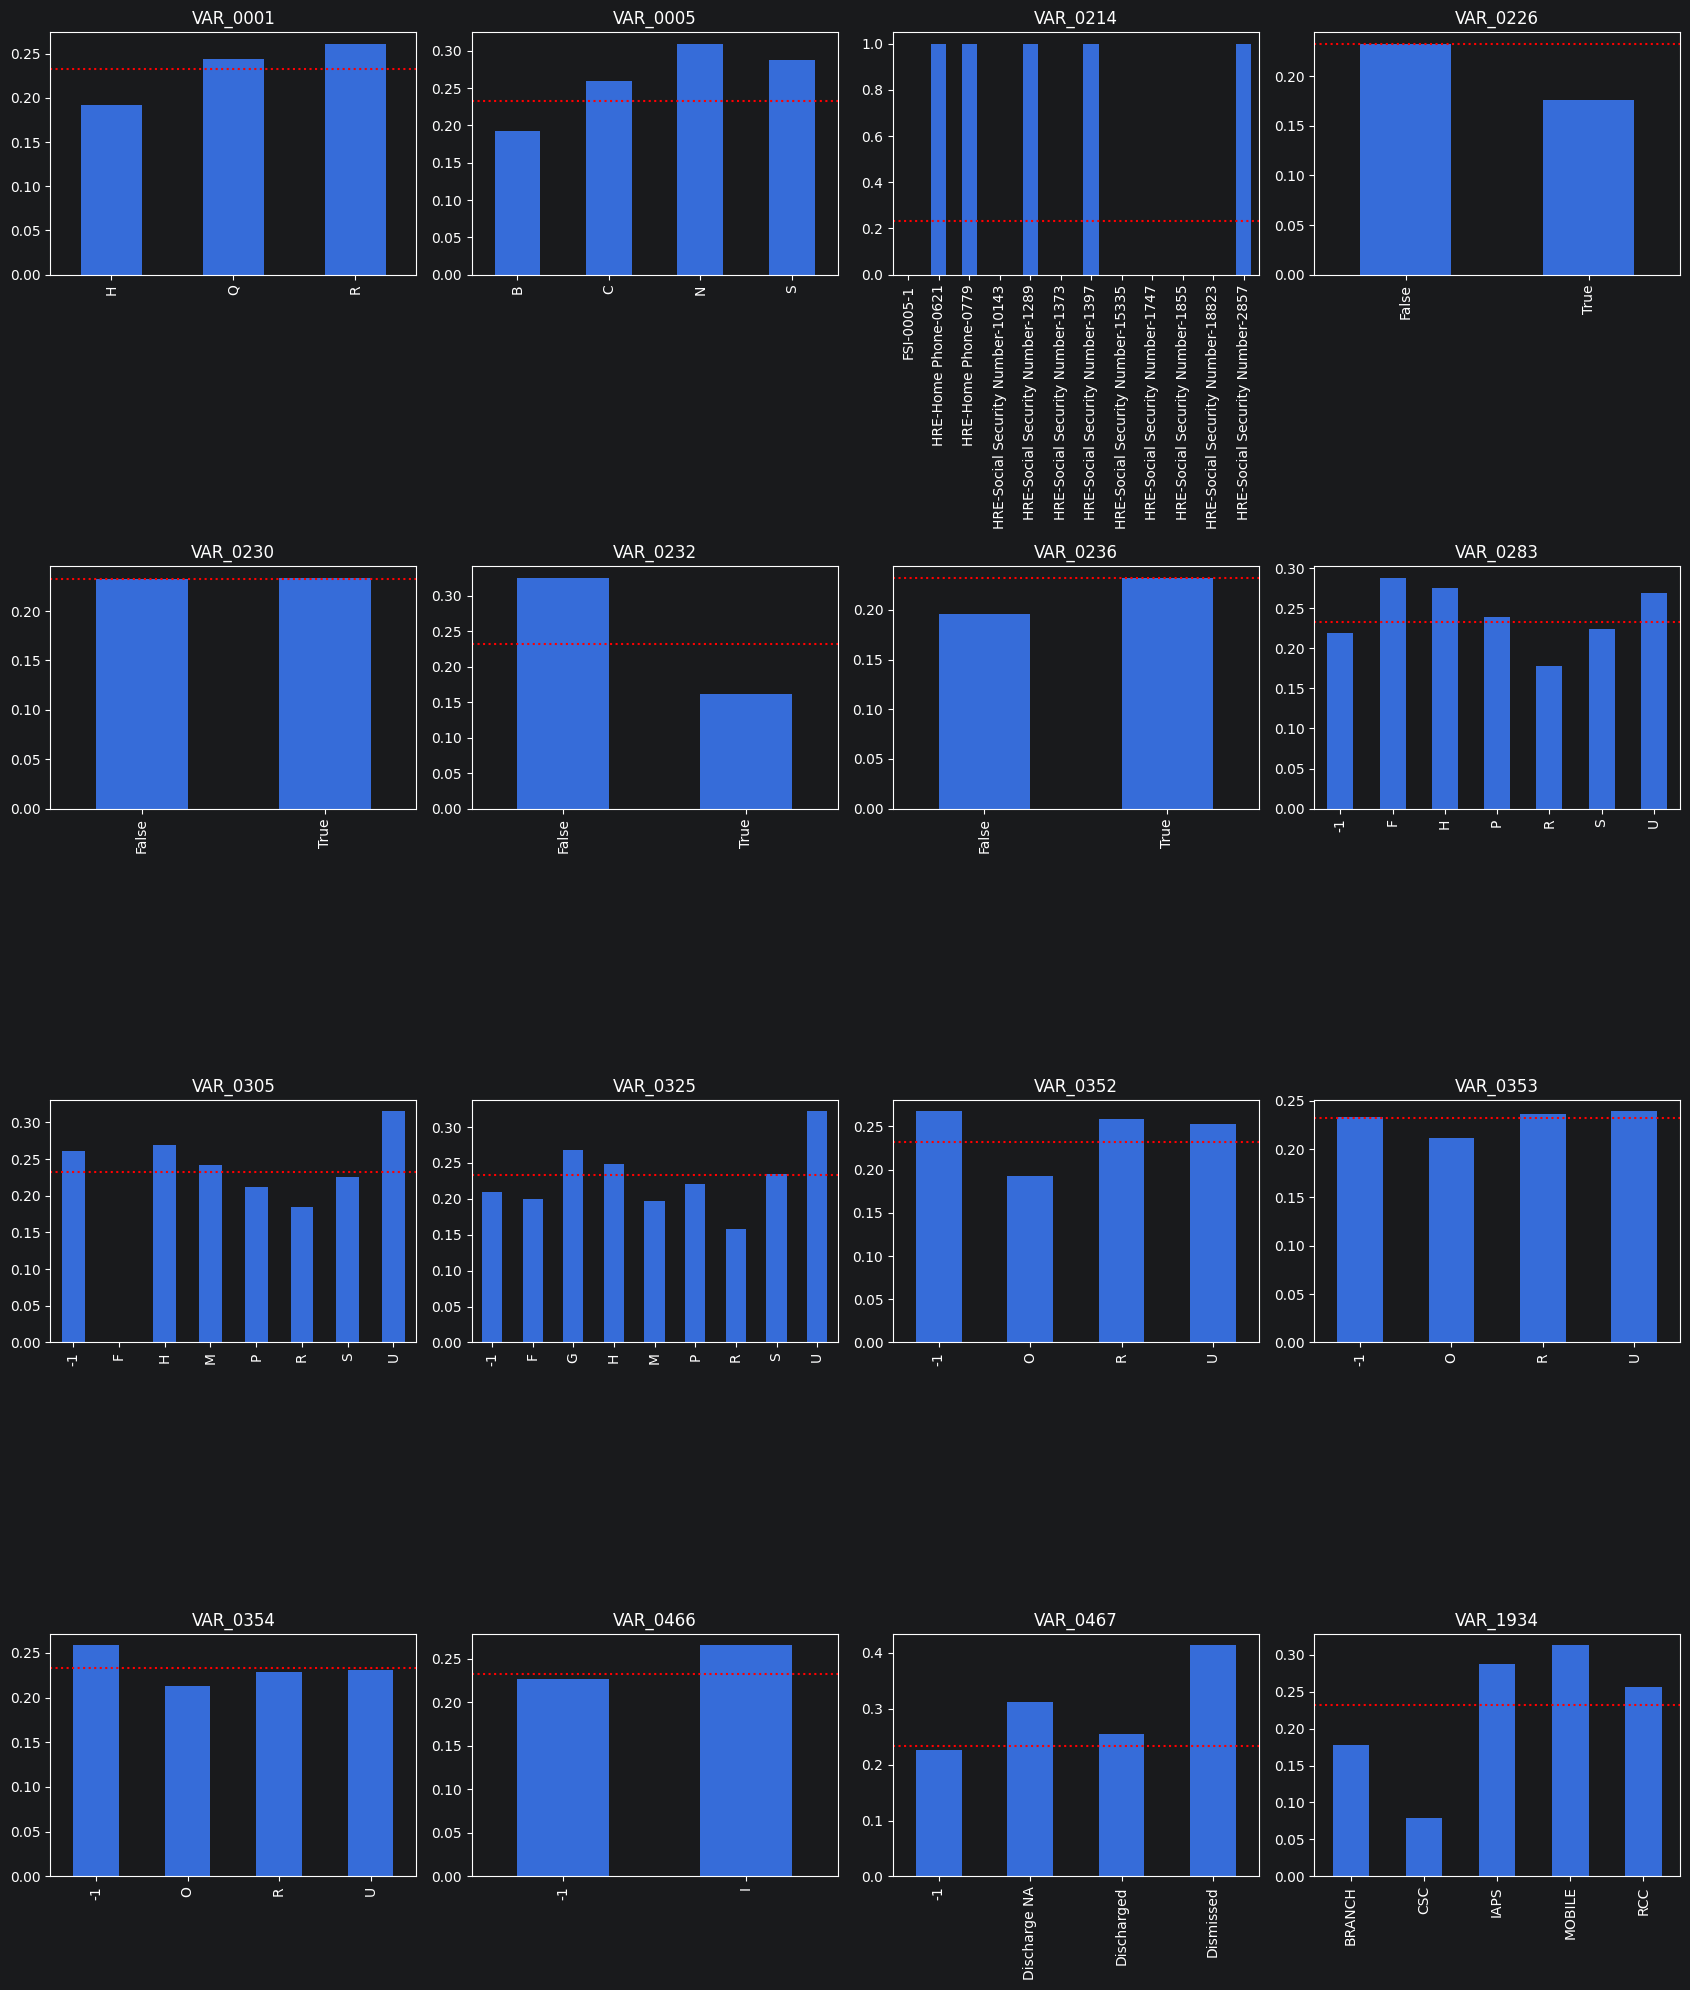

In [22]:
low_card_text = n_unique[(kind == 'text') & (n_unique >= 2) & (n_unique <= 20)].index
n_rows = (len(low_card_text) + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(17, 5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, low_card_text):
    df.groupby(col)['target'].mean().plot.bar(ax=ax)
    ax.axhline(df['target'].mean(), color='red', linestyle='dotted')
    ax.set_title(col)
    ax.set_xlabel('')
for ax in axes[len(low_card_text):]:
    ax.remove()

plt.tight_layout()
plt.show()

In [35]:
# TODO Promising features, why?

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature.
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

In [29]:
constant_features = n_unique[n_unique <= 1].index
df_clean = df.drop(columns=constant_features)

print(f'Dropped {len(constant_features)} constant columns.')
check_cols = [c for c in df_clean.columns if c not in ('ID', 'target')]
column_hash = df_clean[check_cols].apply(lambda s: pd.util.hash_pandas_object(s, index=False).sum())
duplicate_features = column_hash[column_hash.duplicated()].index
df_clean = df_clean.drop(columns=duplicate_features)

print(f'Dropped {len(duplicate_features)} duplicate features.')
print(f'Columns before cleaning: {df.shape[1]}')
print(f'Columns after cleaning: {df_clean.shape[1]}')

min_support = 100
support_count = df_clean.drop(columns=['ID', 'target']).notna().sum()
low_support_features = support_count[support_count < min_support].index
df_clean = df_clean.drop(columns=low_support_features)

print(f'Dropped {len(low_support_features)} features with fewer than {min_support} non-null rows.')
print('These hold too little data for any statistic on them to mean anything.')
for col in low_support_features:
    print(f'{col}: {support_count[col]} non-null rows')
print(f'Columns remaining: {df_clean.shape[1]}')


print('Date clean-up work, just making some reasonable assumptions.\n')
date_format = '%d%b%y:%H:%M:%S'
reference_date = pd.Timestamp('2010-01-01')

text_features = df_clean.drop(columns=['ID', 'target']).select_dtypes(exclude=[np.number]).columns

date_features = []
category_features = []

for col in text_features:
    parsed = pd.to_datetime(df_clean[col], format=date_format, errors='coerce')
    filled = df_clean[col].notna()
    if filled.sum() > 0 and parsed[filled].notna().mean() > 0.5:
        df_clean[col] = (parsed - reference_date).dt.days
        date_features.append(col)
    else:
        df_clean[col] = df_clean[col].astype('category').cat.codes.replace(-1, np.nan)
        category_features.append(col)

print('If a column can parse as a date, it will be categorized as one.')
print('Otherwise, it will be a categorical column. This is only in regards to text columns.')

Dropped 54 constant columns.
Dropped 14 duplicate features.
Columns before cleaning: 1934
Columns after cleaning: 1866
Date clean-up work, just making some reasonable assumptions.

If a column can parse as a date, it will be categorized as one.
Otherwise, it will be a categorical column. This is only in regards to text columns.


In [28]:
print('For our choice of ML model, rescaling is not needed. HistGradientBoostingClassifier works well')
print('with unscaled data. We avoided one-hot encoding because this would massively expand the width')
print('of our already impractically wide dataframe.\n')

For our choice of ML model, rescaling is not needed. HistGradientBoostingClassifier works well
with unscaled data. We avoided one-hot encoding because this would massively expand the width
of our already impractically wide dataframe.



In [15]:
print('Here we will take a closer look at the "assumed placeholder" values from earlier.')
print("it's possible that these are actually ordinary or max values of the features.\n")

placeholder_families = {}
for value in assumed_placeholders:
    width = len(str(abs(value)))
    placeholder_families.setdefault(width, []).append(value)

spike_threshold = 0.01
example_col = 'VAR_0602'
before_values = df_clean[example_col].copy()

numeric_col = df_clean.select_dtypes(include=[np.number]).columns.drop(['ID', 'target'])

replaced_cells = 0
replaced_columns = []

for col in numeric_col:
    for family in placeholder_families.values():
        values = df_clean[col]
        is_code = values.isin(family)
        if is_code.sum() == 0:
            continue

        rest = values[~is_code].dropna()
        if len(rest) == 0:
            detached = True
            spiked = True
        else:
            codes = values[is_code]
            gap_above = codes.min() - rest.max()
            gap_below = rest.min() - codes.max()
            gap = max(gap_above, gap_below)
            span = rest.max() - rest.min()
            detached = gap > span
            spiked = is_code.mean() > spike_threshold
        if detached or spiked:
            df_clean[col] = values.mask(is_code)
            replaced_cells += is_code.sum()
            replaced_columns.append(col)

print('Placeholder handling:')
print('The families are grouped out of assumed_placeholders by digit width.')
print('A placeholder value is replaced with NaN if either test passes.')
print('Detached: the gap between it and the real values is wider than their whole range.')
print(f'Spiked: it holds more than {spike_threshold:.0%} of the column on its own.')
print(f'Replaced {replaced_cells} placeholder values with NaN.')
print(f'Columns affected: {len(set(replaced_columns))}')
print(f'Missing values now: {df_clean[numeric_col].isna().sum().sum()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before_values.plot.hist(bins=50, ax=axes[0])
axes[0].set_title(f'{example_col} before')

df_clean[example_col].plot.hist(bins=50, ax=axes[1])
axes[1].set_title(f'{example_col} after')

plt.tight_layout()
plt.show()

print(f'{example_col} shows what the cleaning actually does.')
print(f'Non-null rows before: {before_values.notna().sum()}')
print(f'Non-null rows after: {df_clean[example_col].notna().sum()}')
print('The placeholder was hiding the real distribution, which only spans 0 to 990.')

X = df_clean.drop(columns=['ID', 'target'])
y = df_clean['target']

Here we will take a closer look at the "assumed placeholder" values from earlier.
it's possible that these are actually ordinary or max values of the features. 

Placeholder handling:
A placeholder value is replaced with NaN if either test passes.
Replaced 58444354 placeholder values with NaN.
Columns affected: 1061
Missing values now: 61256639


## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


In [16]:
# We removed un-needed columns already in the previous section, discrimation based mostly on
# the fact that some columns contained literally no data or were duplicated.

# We used a more "manual" version of this in class, but I prefer this method.
X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=0, stratify=y_rest)

print('Splitting into train, validation, and test (60/20/20):')
print('stratify keeps the same response rate in every split, and random_state')
print('makes the split repeatable.')
print(f'train: {len(X_train)} rows, {y_train.mean():.4f} response rate')
print(f'validation: {len(X_val)} rows, {y_val.mean():.4f} response rate')
print(f'test: {len(X_test)} rows, {y_test.mean():.4f} response rate')

Splitting into train, validation, and test (60/20/20):
stratify keeps the same response rate in every split, and random_state
makes the split repeatable.
train: 87138 rows, 0.2326 response rate
validation: 29046 rows, 0.2325 response rate
test: 29047 rows, 0.2326 response rate


In [17]:
from sklearn.ensemble import HistGradientBoostingClassifier

model = HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05, early_stopping=True, validation_fraction=0.1, random_state=0)
model.fit(X_train, y_train)

print('HistGradientBoostingClassifier was chosen for four reasons:')
print('I (Christian) happened to randomly choose it for lab 8, so I\'m a little familiar with it')
print('It reads NaN natively, so the missing data needs no imputing,')
print('it needs no rescaling, since its tree-based,')
print('and apparently its well-suited for very wide data.')
print(f'Training stopped after {model.n_iter_} of {model.max_iter} iterations.')

HistGradientBoostingClassifier was chosen for four reasons:
I (Christian) happened to randomly choose it for lab 8, so I'm a little familiar with it
It reads NaN natively, so the missing data needs no imputing,
it needs no rescaling, since trees split on thresholds,
and it handles wide tabular data well.
Training stopped after 214 of 500 iterations.


Evaluation on the validation set:
Kaggle scored this problem on AUC, which is why we selected it here.
AUC: 0.7824


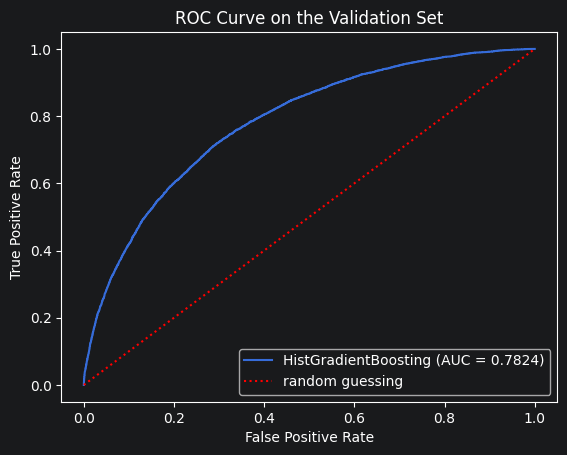

In [26]:
val_scores = model.predict_proba(X_val)[:, 1]
val_predictions = model.predict(X_val)
val_auc = roc_auc_score(y_val, val_scores)

print('Evaluation on the validation set:')
print('Kaggle scored this problem on AUC, which is why we selected it here.')
test_scores = model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_scores)

print(f'Validation AUC: {val_auc:.4f}')
print(f'Test AUC: {test_auc:.4f}')
print('The test set was only touched here, so the two agreeing means the model is not')
print('overfitting to the validation set.')
print(f'Accuracy: {accuracy_score(y_val, val_predictions):.4f}')
print(f'Accuracy from always predicting 0: {1 - y_val.mean():.4f}')
print('Accuracy barely moves off the baseline, which is why AUC is the metric here.')

fpr, tpr, thresholds = roc_curve(y_val, val_scores)

plt.plot(fpr, tpr, label=f'HistGradientBoosting (AUC = {val_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='dotted', color='red', label='random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on the Validation Set')
plt.legend()
plt.show()

In [34]:
# TODO Kaggle submission.